## Problem 1 (8 points): Mathematical Model of the DLL

**Goal of this problem**: In problem set 2, we generated the PRN codes and demonstrated correlation over the entire 1023 chip sequence. Locating that single chip with the peak is more akin to acquisition. In this problem, students will mathematically assess the impacts of errors on the delay lock loop (DLL).


Recall that our DLL correlator outputs will be affected by noise. In lecture, we represented the early and late correlator outputs as:

$$
Z_E = S_E + N_E, \quad\quad
Z_L = S_L + N_L,
$$

where $S_E$ and $N_E$ are the signal and noise components of the early correlator sample, and $S_L$ and $N_L$ are the signal and noise components of the late correlator sample, in units of square root of power (i.e., $\sqrt{\text{W}}$). The $\tau$ chip offset that makes $S_E = S_L$ corresponds to the ideal pseudorange (i.e., no errors other than satellite and user clock). However, we cannot directly obtain $S_E$ and $S_L$ due to the noise terms. Instead, we only have access to the outputs $Z_E$ and $Z_L$.

How will $N_E$ and $N_L$ affect our measured pseudorange? Figure 1 depicts how these noise components affect the early-minus-late DLL discriminator function. We have chosen to plot the $\Delta \tau$ axis centered on the ideal chip offset to assess the error in the pseudorange.

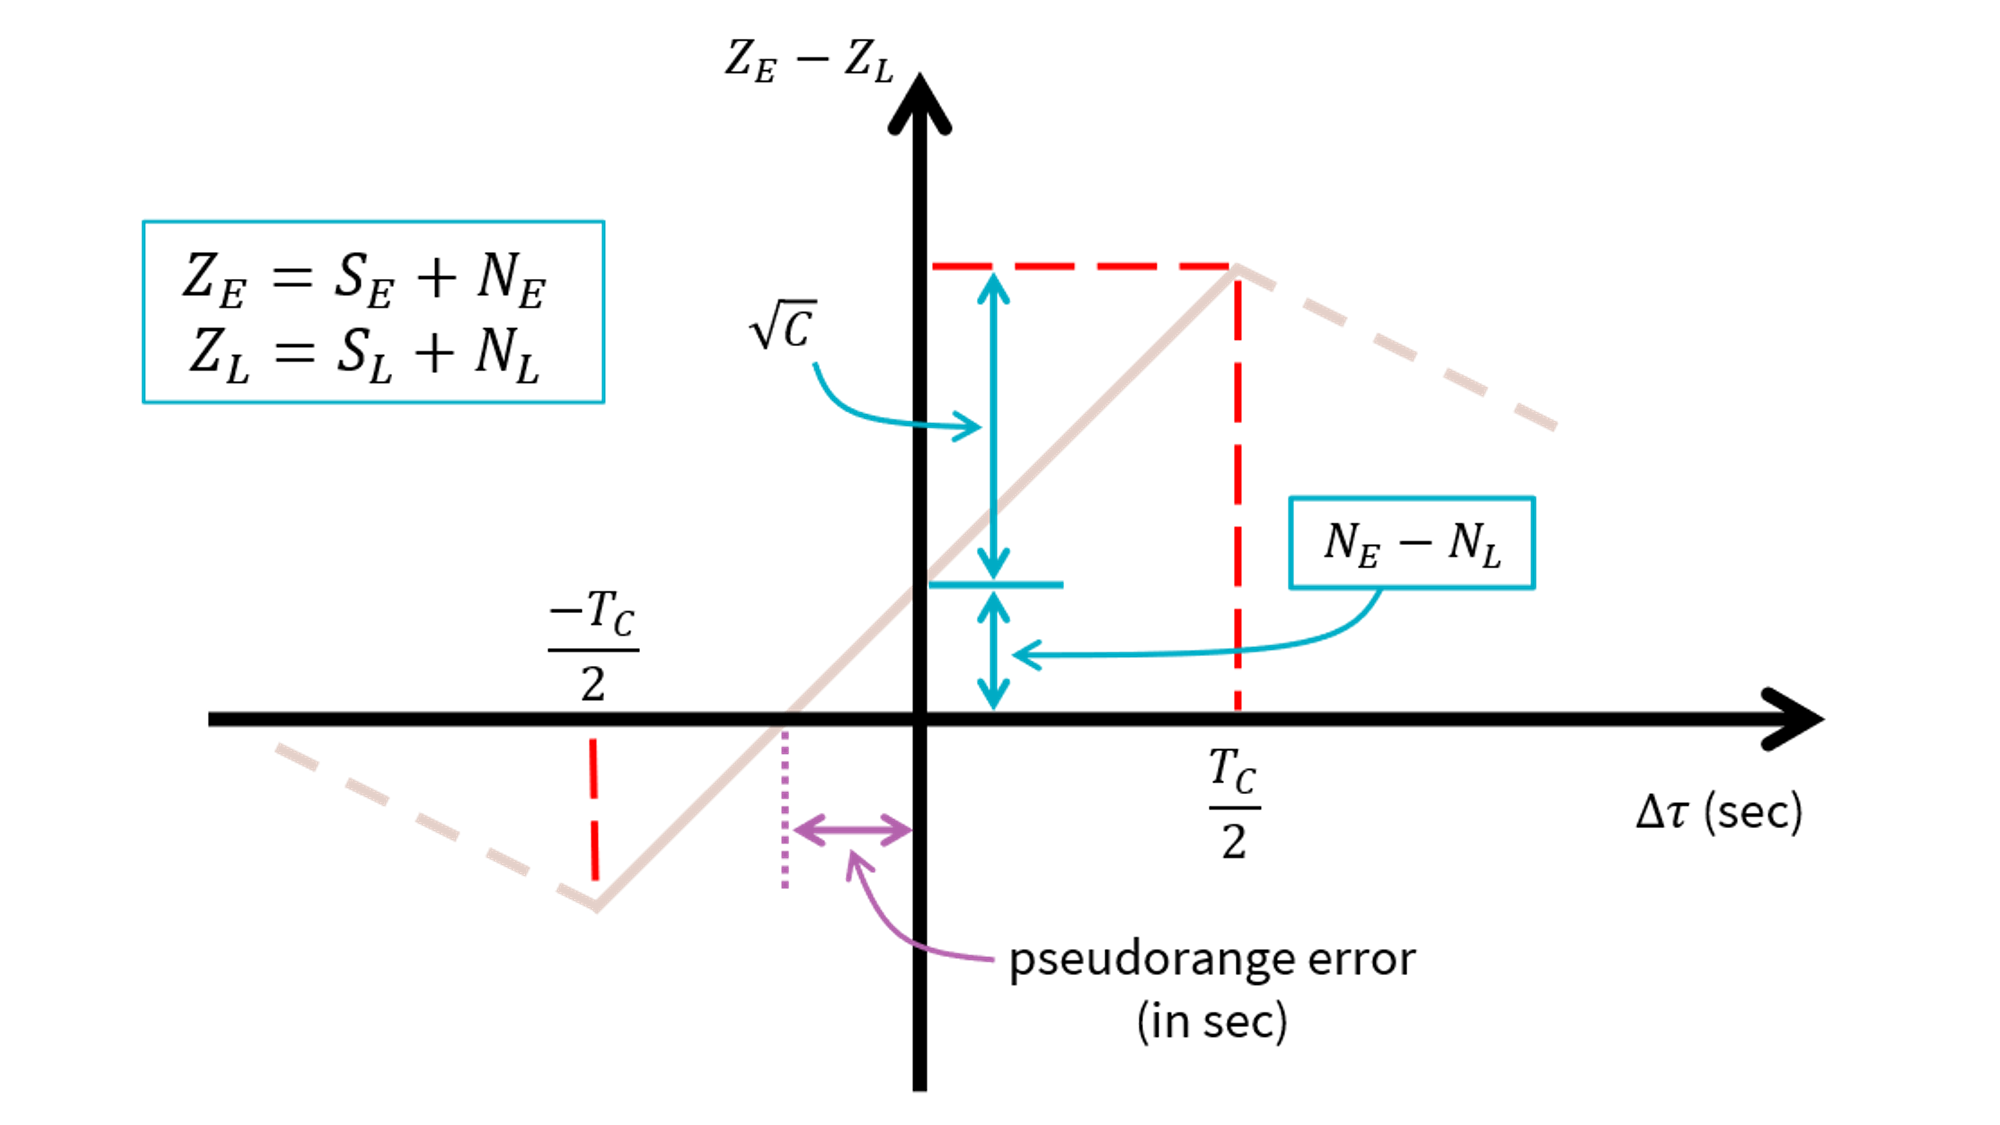


Figure 1.1: Depiction of early-minus-late discriminator function in presence of noise.
$T_C$ represents the chip width and $C$ represents the received signal power.
We observe that these noise terms lead to a vertical shifting of the discriminator function, which results in a shifted "zero crossing" for the discriminator and a corresponding error in the pseudorange. Note that this discriminator is plotted for a correlator spacing of $d=1$ chip.

The noise model in this problem is a good model of some noise, such as thermal noise or error sources that change the variance in the pseudorange. Thinking back to problem 2 on homework 2, we can use the intuition from this model for selecting appropriate weights in weighted least squares. However, this model does not capture the uncorrected delays in signal reception that induce biases in the measured pseudorange. In particular, the shape of the discriminator above is not a good model for multipath, which is what the next problem will handle. That said, this model will take you a long way in understanding pseudorange uncertainty.

### 1.1 Pseudorange Error [2 points]

Using Figure 1.1 as a reference, show step-by-step how we can derive an expression for the induced pseudorange error **in meters** in terms of $N_E$ and $N_L$. Clearly indicate your final expression as well.

*Hint:* Lecture slides may prove helpful to check your final answer.

*Hint:* $N_E$ and $N_L$ are in units of $\sqrt{\text{W}}$. $T_C$ is in units of seconds.

Representing the error as $\tau$ in meters. Since the pseudorange error is in units of seconds, it must be multiplied by the speed of light to correct its units.

$$ slope\ = \frac{rise}{run} = \frac{N_E - N_L}{c \tau} = \frac{N_E - N_L + \sqrt{C}}{c \frac{T_c}{2} + \tau}$$

$$\frac{T_c}{2}(N_E - N_L) + c \tau (N_E - N_L) = (N_L - N_L + \sqrt{C}) c \tau$$

$$\frac{T_c}{2}(N_E - N_L)= \sqrt{C} c \tau$$

$$\tau = \frac{cT_C (N_E - N_L)}{2\sqrt(C)}$$

### 1.2 Probability Distribution [4 points]

Suppose that $N_E$ and $N_L$ come from a zero-mean Gaussian distribution with variance $\sigma_N^2$, i.e., $N_E, N_L \sim \mathcal{N}(0, \sigma_N^2)$. Using the expression found in part (a), derive the probability distribution for the corresponding pseudorange error (keep your terms **in meters**).

*Hint 1:* For an early-minus-late correlator spacing of $d=1$ chip (as shown in Figure 1.1), we can assume that $N_E$ and $N_L$ are uncorrelated.

*Hint 2:* If a random variable is Gaussian, you only need to compute the mean $\mu_\rho$ and standard deviation $\sigma_\rho$ to define its distribution.

*Hint 3:* Recall that the mean is defined as $\mu_\rho := \mathbb{E}\left[ \text{pseudorange error} \right]$ and the variance is defined as $\sigma_\rho^2 := \mathbb{E}\left[ \left(\text{pseudorange error} - \mu_\rho\right)^2 \right]$.

*Hint 4:* Linear combinations of Gaussian random variables is still Gaussian. So, you will not need to do any integrals for this problem, just some algebraic work.

***ANSWER***

Adding gaussian distributions adds the means and the standard distribution. Assuming $\sqrt{C}$ is a constant, the resulting pseudorange error distribution is as follows:

$$\tau = \frac{cT_C}{2\sqrt(C)} (N_E - N_L) $$

$$\tau = \frac{cT_C}{2\sqrt(C)} (\ N(0, \sigma_N^2) - N(0, \sigma_N^2\ )) $$

$$\tau = \frac{cT_C}{2\sqrt(C)} N(0, 2 \sigma_N^2) $$

$$\sigma_\rho^2 =  2 \sigma_N^2 * \left( \frac{cT_C}{2\sqrt(C)} \right)^2 $$

$$\sigma_\rho^2 =  2 \sigma_N^2 \frac{c^2 T_c^2}{4C} $$

$$\sigma_\rho^2 =  \frac{ \sigma_N^2 c^2 T_c^2}{2C} $$

### 1.3 Pseudorange Precision [1 point]

For reasons beyond the current discussion, we can model the variance $\sigma_N^2$ via

$$\sigma_N^2 = \frac{N_0}{2T}$$

where $N_0$ is the noise density ratio (in units of power per frequency or $\text{W}/\text{Hz}$) and $T$ is the averaging time (in units of seconds). In problem 3 of homework 3, we were correlating across 1023 chips. However, we could have continued correlating beyond 1023 chips using the periodic nature of the PRN codes. Correlating or averaging over a longer amount of time will diminish the impact of the noise and give us a clearer peak. You may want to revisit the lecture slides, with attention to the elapsed time, to see this in action.

The quantity carrier-to-noise-density ratio ($C/N_0$) is the quantity we referred to loosely as signal strength in the lectures, and the GNSS Logger App. Most people (including the developers of the GNSS Logger App and many chipset manufacturers) will report $C/N_0$ in decibel-Hertz (dB-Hz), whereas the subsequent calculations are more straightforward without the decibel conversion such that $C/N_0$ has units of Hertz. A nice property of $C/N_0$ is that we can estimate it using the measured power in the received signal and the correlation process we already do as part of CDMA.

Plug in this expression of $\sigma_N^2$ into your standard deviation equation above to derive the change in pseudorange precision (i.e., $\sigma_\rho$) based on the $C/N_0$. Please isolate the term $C/N_0$ in parentheses for readability.

***ANSWER***

$$\tau =  N\left(0,  \frac{ \sigma_N^2 c^2 T_c^2}{2C} \frac{N_0}{2T}\right)$$

$$\sigma_\rho^2 =  \frac{c^2 T_c^2}{2C} \frac{N_0}{2T}$$

$$\sigma_\rho^2 =  \frac{ c^2 T_c^2}{4T} \left(C/N_0\right)^{-1}$$

### 1.4 Tracking Performance [1 point]

Given that the military GPS L1 P(Y) signal's chipping rate is 10 times faster than the civilian GPS L1 C/A, how will the pseudorange error and tracking performance of the military signal compare with that of the civilian signal? Use your derived expression from part (2) to justify your conclusions.

*Hint:* You will want to look at standard deviation **not variance** since standard deviation is in units of meters, but variance is in units of meters squared.

*Side-note:* The modernized GPS L5 and Galileo E5 civilian signals also have a 10 times faster chipping rate, but it is transmitted in a different band (namely, the L5/E5 band).

***ANSWER***

Because the military signal has a 10 times faster chipping rate, the chirp period is is 10 times smaller. From our $\sigma_\rho$ formula, $\sigma_\rho \propto T_c$, so the pseudorange error standard deviation decreases by a factor of 10, improving tracking precision.